# Business Questions:

**Operational:**

Which teams are the slowest to resolve incidents?

What types of incidents occur most often?

Which categories generate the most SLA violations?

Do weekend incidents have a longer resolution time?

**Process:**

Where do bottlenecks occur?

Do high priority actually shorten resolution time?

How often are incidents reopened?

Which teams have the highest reopen rate?

**Management:**

What process improvements can shorten incident resolution time?

In [35]:
#EDA (Exploratory Data Analysis)
#Importing the dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("incidents.csv")

df.head()

,incident_id,created_date,resolved_date,priority,category,assigned_team,sla_breached,reopen_count,resolution_minutes
0,1,2024-05-07 11:34:00,2024-05-07 17:11:00,Low,Application,Infra_Team,0,1,337
1,2,2024-05-31 22:14:00,2024-06-01 09:11:00,Low,Database,Infra_Team,1,0,657
2,3,2024-02-01 13:10:00,2024-02-01 15:12:00,Low,Application,DB_Team,0,0,122
3,4,2024-03-20 13:47:00,2024-03-20 17:48:00,High,Security,App_Team,1,0,241
4,5,2024-05-09 15:21:00,2024-05-10 06:07:00,Low,Application,Support_Team,1,0,886


In [36]:
#Data Overview
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   incident_id         5000 non-null   int64 
 1   created_date        5000 non-null   object
 2   resolved_date       5000 non-null   object
 3   priority            5000 non-null   object
 4   category            5000 non-null   object
 5   assigned_team       5000 non-null   object
 6   sla_breached        5000 non-null   int64 
 7   reopen_count        5000 non-null   int64 
 8   resolution_minutes  5000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 351.7+ KB


,incident_id,sla_breached,reopen_count,resolution_minutes
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,0.647400,0.290200,498.638800
std,1443.520003,0.477827,0.539298,579.602789
min,1.000000,0.000000,0.000000,0.000000
25%,1250.750000,0.000000,0.000000,112.000000
50%,2500.500000,1.000000,0.000000,302.000000
75%,3750.250000,1.000000,1.000000,665.000000
max,5000.000000,1.000000,4.000000,5778.000000


In [37]:
#Deleting Incidents where time is 0 minutes

count = 0

for i in df["resolution_minutes"]:
    if i == 0:
        count+=1

print(f"Tere is {count} incidents that tooks 0 minutes")

df = df[df["resolution_minutes"] > 0]

Tere is 14 incidents that tooks 0 minutes


In [38]:
analysis_table = df.groupby("assigned_team").agg(

    incident_count = ("incident_id","count"),
    avg_resolution_minutes = ("resolution_minutes","mean"),
    sla_breach_rate = ("sla_breached","mean"),
    avg_reopen = ("reopen_count","mean")

).reset_index()

analysis_table

,assigned_team,incident_count,avg_resolution_minutes,sla_breach_rate,avg_reopen
0,App_Team,996,500.532129,0.644578,0.263052
1,DB_Team,997,494.645938,0.645938,0.269809
2,Infra_Team,964,519.227178,0.647303,0.282158
3,Security_Team,1009,493.849356,0.638256,0.324083
4,Support_Team,1020,492.816667,0.669608,0.307843


In [39]:
#Adding the colum that helps to decide did Incident happened on the Weekday or Weekend
df["created_date"] = pd.to_datetime(df["created_date"])

df["day_type"] = df["created_date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

df["day_type"].value_counts()

Weekday    3630
Weekend    1356
Name: day_type, dtype: int64

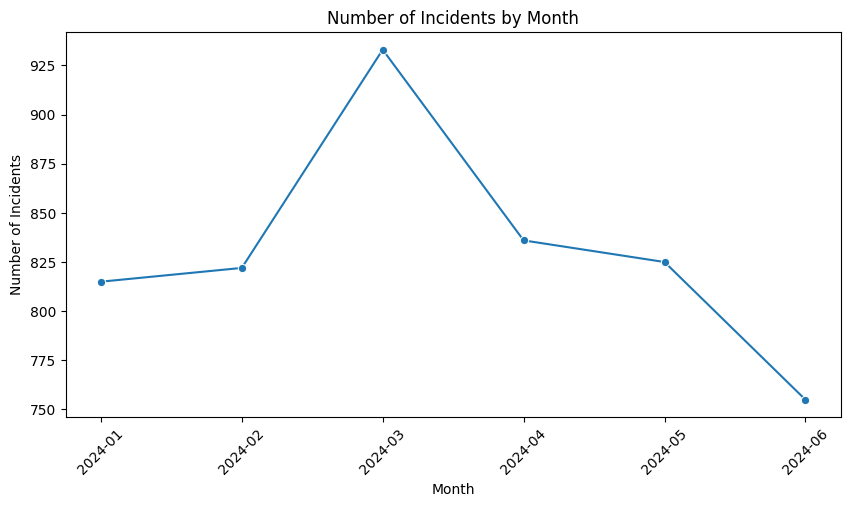

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

df["created_date"] = pd.to_datetime(df["created_date"])
df["month"] = df["created_date"].dt.to_period("M")
incidents_by_month = df.groupby("month").size()

plt.figure(figsize=(10,5))


sns.lineplot(
    x=incidents_by_month.index.astype(str),
    y=incidents_by_month.values,
    marker="o"
)

plt.title("Number of Incidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

In [41]:
#We can spot some outlayers over one day = 24h = 60 min * 24 = 1440 min

outliers = df[df["resolution_minutes"] > 1440]
count = (df["resolution_minutes"] > 1440).sum()

print(f"Tere is {count} incidents that tooks over 1 day")


#There is a possibility to look only for Incidents that tooks over 1 day
#longDf = df[df["resolution_minutes"] > 1440]

Tere is 348 incidents that tooks over 1 day


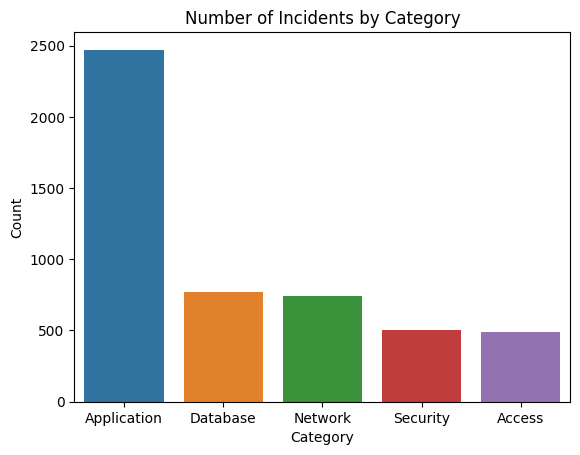

In [42]:
#Number of Incidents by Category
category_counts = df["category"].value_counts()

plt.figure()
sns.barplot(x=category_counts.index, y=category_counts.values)

plt.title("Number of Incidents by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

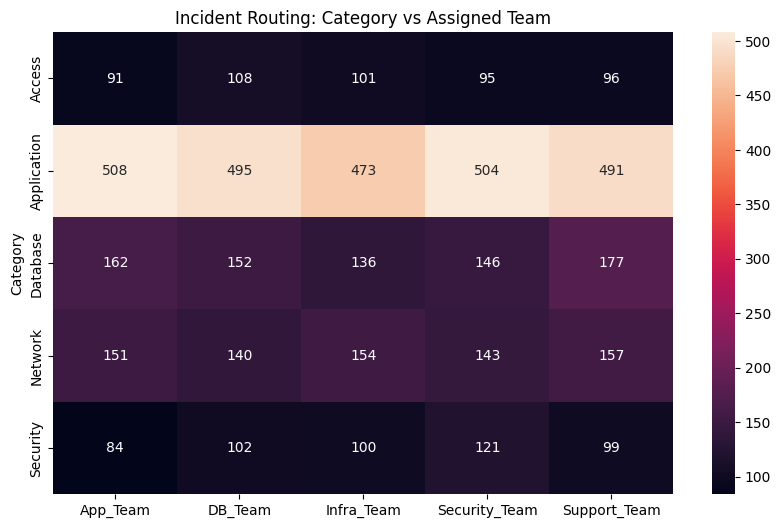

In [43]:
#Incident Routing: Category vs Assigned Team
plt.figure(figsize=(10,6))

pivot = pd.crosstab(
    df["category"],
    df["assigned_team"],
)

sns.heatmap(pivot, annot=True, fmt="d")

plt.title("Incident Routing: Category vs Assigned Team")

plt.xlabel("")
plt.ylabel("Category")

plt.show()

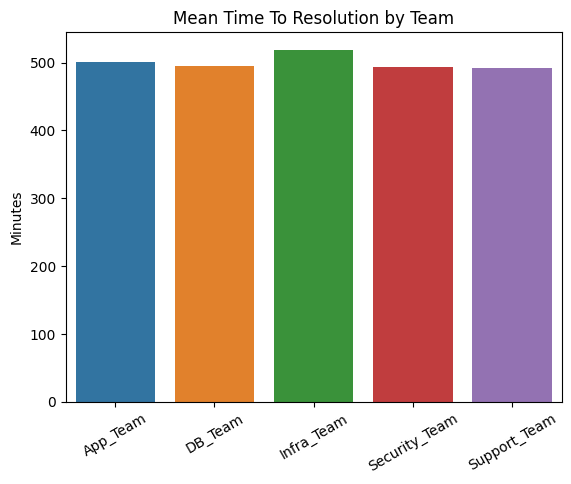

In [44]:
#MTTR Mean Time To Resolution
mttr = df.groupby("assigned_team")["resolution_minutes"].mean()

plt.figure()

sns.barplot(x=mttr.index, y=mttr.values)

plt.title("Mean Time To Resolution by Team")
plt.ylabel("Minutes")
plt.xlabel("")

plt.xticks(rotation=30)

plt.show()

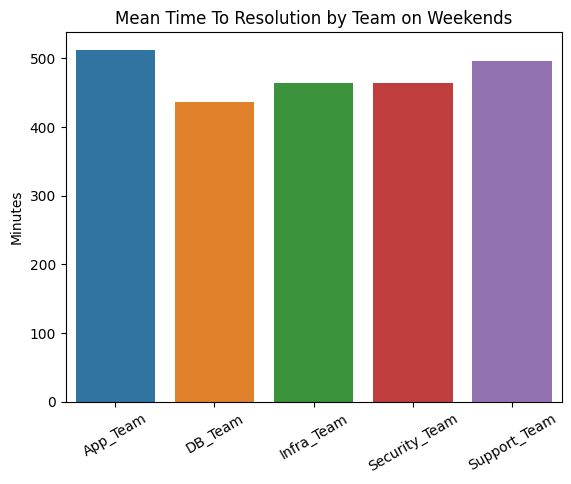

In [45]:
#MTTR Mean Time To Resolution on Weekends
mttr = df[df["day_type"] == "Weekend"].groupby("assigned_team")["resolution_minutes"].mean()


plt.figure()

sns.barplot(x=mttr.index, y=mttr.values)

plt.title("Mean Time To Resolution by Team on Weekends")
plt.ylabel("Minutes")
plt.xlabel("")

plt.xticks(rotation=30)

plt.show()

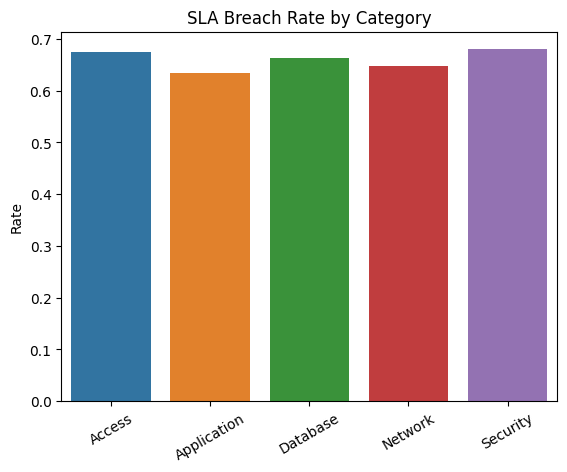

In [46]:
#SLA Breach Rate by Category (Service Level Agreement)
sla_rate = df.groupby("category")["sla_breached"].mean()

plt.figure()
sns.barplot(x=sla_rate.index, y=sla_rate.values)

plt.title("SLA Breach Rate by Category")
plt.xlabel("")
plt.ylabel("Rate")

plt.xticks(rotation=30)

plt.show()

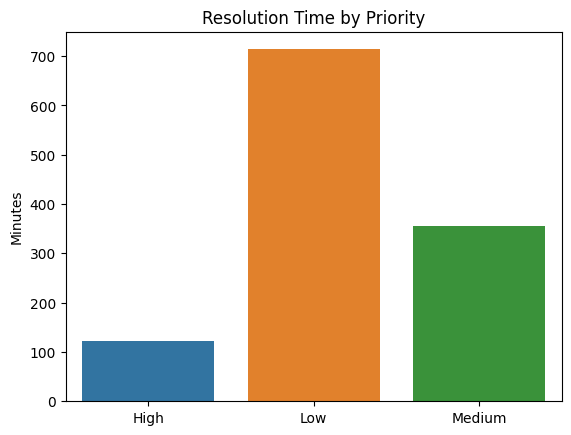

In [47]:
#Resolution Time by Priority
priority_resolution = df.groupby("priority")["resolution_minutes"].mean()

sns.barplot(x=priority_resolution.index, y=priority_resolution.values)

plt.title("Resolution Time by Priority")
plt.xlabel("")
plt.ylabel("Minutes")

plt.show()

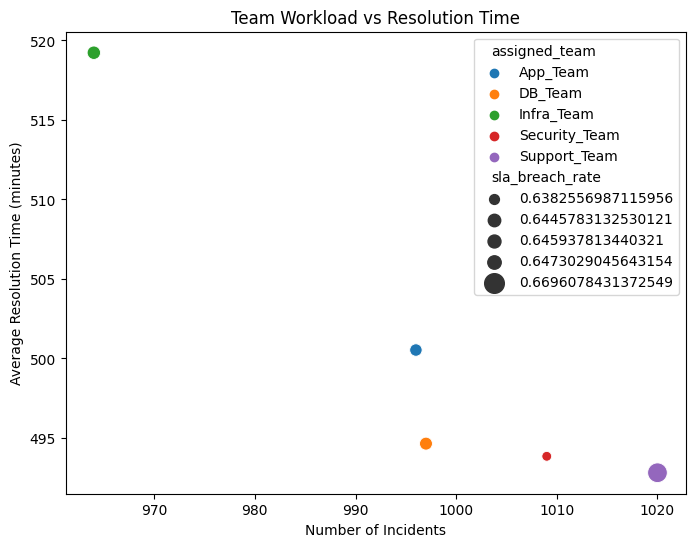

In [49]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=analysis_table,
    x="incident_count",
    y="avg_resolution_minutes",
    size="sla_breach_rate",
    hue="assigned_team",
    sizes=(50,200)
)

plt.title("Team Workload vs Resolution Time")

plt.xlabel("Number of Incidents")
plt.ylabel("Average Resolution Time (minutes)")

plt.show()

# Key Insights

**Operational:**

Which teams resolve incidents the slowest?

_The average incident resolution time is similar across each team._

What types of incidents occur most often?

_Application incidents are the most common._

Which categories generate the most SLA violations?

_Security and Access generate the most violations._

_However, the SLA Breach Rate is high. Therefore, it's necessary to consider redefining the thresholds._

Do incidents occurring on weekends have a longer resolution time?

_No. We can even observe the opposite: DB, Infra, and Security teams work faster on weekends._

**Process:**

Where do bottlenecks occur?

_Each team has a similar number of incidents._

_However, the Application category should be considered, as the highest number of incidents falls into this category._

Does high priority actually shorten resolution time?

_Yes_


How often are incidents reopened?

_One in three incidents is reopened, or more precisely, 29%._

Which teams have the highest reopen rate?

_Security_Team has the highest reopen rate of 0.32._

**Management:**

What process improvements can shorten incident resolution time?

_It's important to consider whether categories and teams are assigned appropriately by employees._